<a href="https://colab.research.google.com/github/SAMAH-prog/application-3D/blob/main/Comparaison.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [48]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, roc_curve, precision_recall_curve
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
import shap

In [49]:
# ====================== GÉNÉRATION DES DONNÉES ======================
def generate_long_term_dataset(n_samples=25000, seed=42):
    np.random.seed(seed)
    data = {
        'historique_crises_12m': np.random.choice([0,1,2,3,4,5], n_samples, p=[0.45,0.25,0.15,0.08,0.04,0.03]),
        'severite_gina': np.random.choice([2,3,4,5], n_samples, p=[0.35,0.40,0.18,0.07]),
        'score_act': np.clip(np.random.normal(19, 4.5, n_samples), 5, 25).astype(int),
        'usage_bronchodilatateur_7j': np.round(np.random.gamma(1.8, 1.4, n_samples), 1).clip(0, 12),
        'age': np.random.randint(18, 61, n_samples),
        'sexe': np.random.choice([0,1], n_samples, p=[0.58,0.42]),
        'imc': np.round(np.random.normal(26.5, 5.5, n_samples), 1).clip(16, 45),
        'pollution_moy_7j': np.round(np.random.gamma(2.2, 22, n_samples), 1).clip(5, 180),
        'pollen_moy_7j': np.round(np.random.gamma(1.6, 75, n_samples), 1).clip(0, 600),
    }

    df = pd.DataFrame(data)

    df['crises_vs_gina'] = df['historique_crises_12m'] * (5 - df['severite_gina'])
    df['environnement'] = df['pollution_moy_7j'] * df['pollen_moy_7j'] / 1000

    risk_score = (
        df['historique_crises_12m'] * 0.25 +
        (5 - df['severite_gina']) * -0.20 +
        (25 - df['score_act']) * 0.032 +
        df['usage_bronchodilatateur_7j'] * 0.095 +
        df['pollution_moy_7j'] * 0.0038 +
        df['pollen_moy_7j'] * 0.0009 +
        df['crises_vs_gina'] * 0.015 +
        df['environnement'] * 0.012 +
        np.random.normal(0, 0.10, n_samples)
    )

    df['risk_score'] = np.clip(risk_score, 0, 1)
    df['target'] = (df['risk_score'] > 0.48).astype(int)
    return df

In [50]:
# ====================== PRÉPARATION ======================
df = generate_long_term_dataset()
features = ['historique_crises_12m', 'severite_gina', 'score_act',
            'usage_bronchodilatateur_7j', 'age', 'sexe', 'imc',
            'pollution_moy_7j', 'pollen_moy_7j', 'crises_vs_gina', 'environnement']

X = df[features]
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [51]:
# ====================== ENTRAÎNEMENT DES DEUX MODÈLES ======================
print("🚀 Entraînement des modèles...")

# 1. XGBoost
scale_pos_weight = len(y_train[y_train==0]) / len(y_train[y_train==1])
xgb_model = xgb.XGBClassifier(
    n_estimators=600, learning_rate=0.06, max_depth=8,
    subsample=0.88, colsample_bytree=0.88,
    scale_pos_weight=scale_pos_weight,
    random_state=42, eval_metric='auc', verbosity=0
)
xgb_model.fit(X_train, y_train)

# 2. Random Forest
rf_model = RandomForestClassifier(
    n_estimators=600,
    max_depth=12,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)

🚀 Entraînement des modèles...


RandomForestClassifier(class_weight='balanced', max_depth=12,
                       min_samples_leaf=2, min_samples_split=5,
                       n_estimators=600, n_jobs=-1, random_state=42)

In [52]:
# ====================== COMPARAISON ======================
models = {'XGBoost': xgb_model, 'Random Forest': rf_model}
results = {}

print("\n" + "="*80)
print("📊 COMPARAISON XGBoost vs Random Forest")
print("="*80)

for name, model in models.items():
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    y_pred = (y_pred_proba >= 0.5).astype(int)

    auc = roc_auc_score(y_test, y_pred_proba)
    acc = model.score(X_test, y_test)

    results[name] = {'AUC': auc, 'Accuracy': acc, 'Proba': y_pred_proba}

    print(f"\n🔹 {name}")
    print(f"AUC          : {auc:.4f}")
    print(f"Accuracy     : {acc:.4f}")
    print(classification_report(y_test, y_pred))


📊 COMPARAISON XGBoost vs Random Forest

🔹 XGBoost
AUC          : 0.9812
Accuracy     : 0.9266
              precision    recall  f1-score   support

           0       0.90      0.90      0.90      1801
           1       0.94      0.94      0.94      3199

    accuracy                           0.93      5000
   macro avg       0.92      0.92      0.92      5000
weighted avg       0.93      0.93      0.93      5000


🔹 Random Forest
AUC          : 0.9791
Accuracy     : 0.9188
              precision    recall  f1-score   support

           0       0.88      0.90      0.89      1801
           1       0.94      0.93      0.94      3199

    accuracy                           0.92      5000
   macro avg       0.91      0.92      0.91      5000
weighted avg       0.92      0.92      0.92      5000



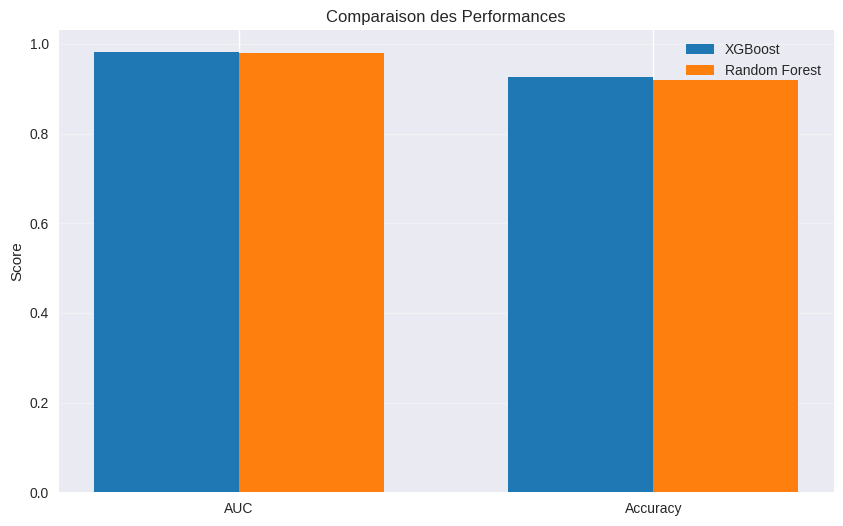

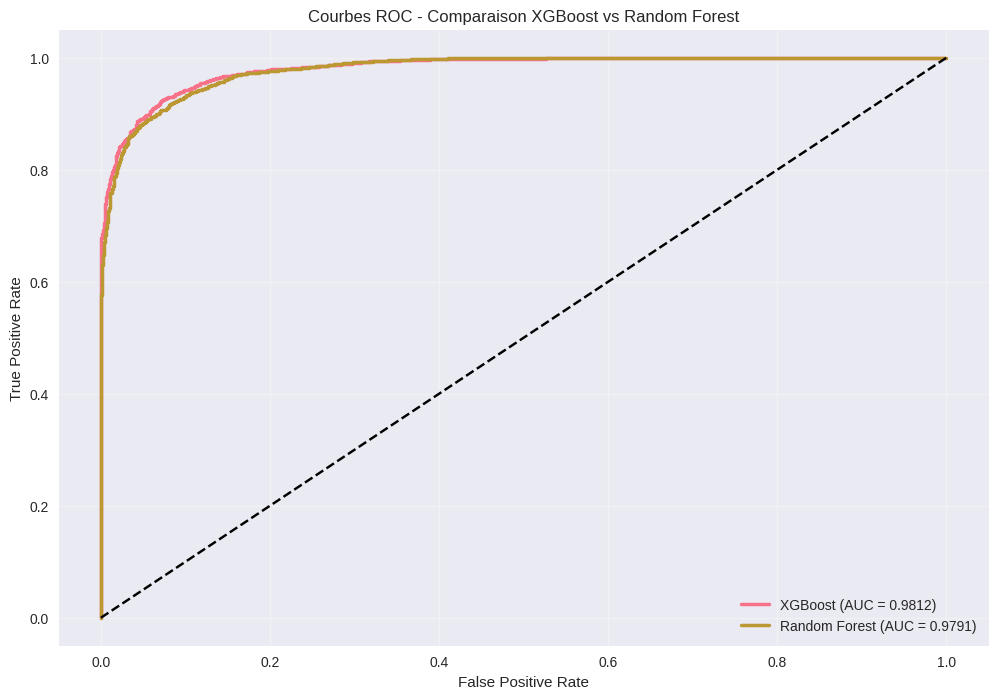

<Figure size 1200x800 with 0 Axes>

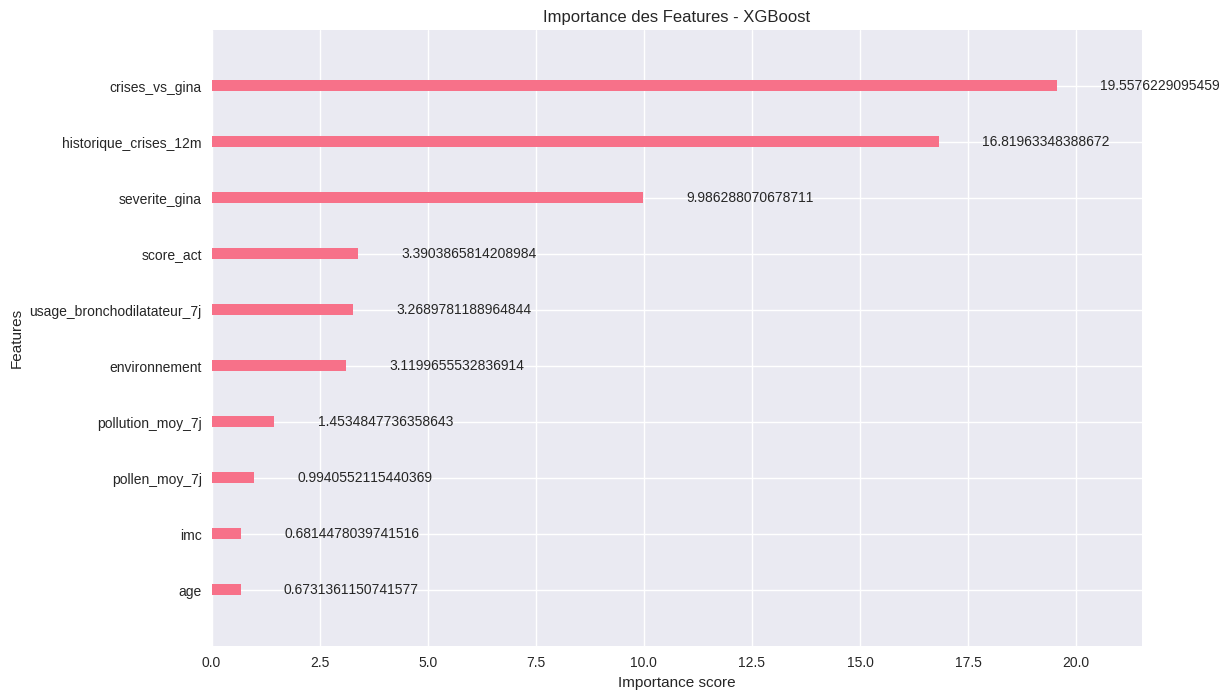

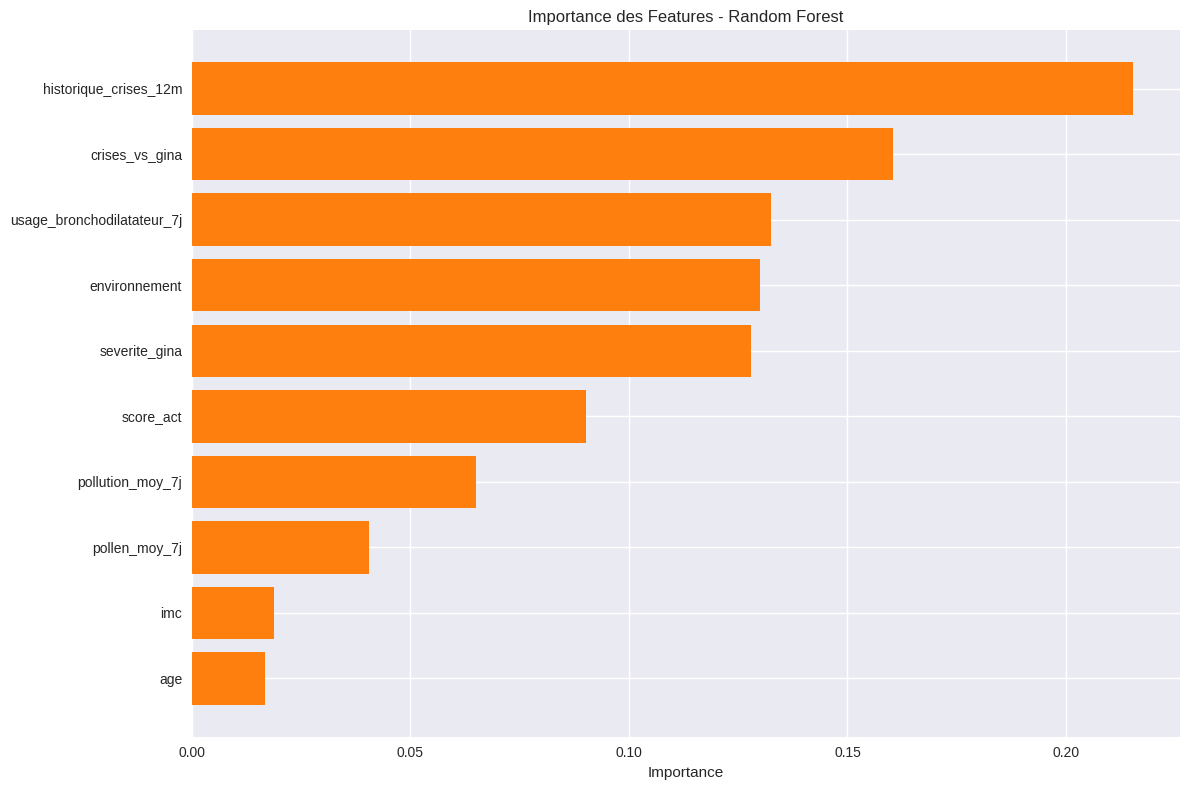

In [53]:
# ====================== GRAPHIQUES DE COMPARAISON ======================

# 1. Comparaison AUC & Accuracy
plt.figure(figsize=(10,6))
metrics = ['AUC', 'Accuracy']
x = np.arange(len(metrics))
width = 0.35

xgb_scores = [results['XGBoost']['AUC'], results['XGBoost']['Accuracy']]
rf_scores  = [results['Random Forest']['AUC'], results['Random Forest']['Accuracy']]

plt.bar(x - width/2, xgb_scores, width, label='XGBoost', color='#1f77b4')
plt.bar(x + width/2, rf_scores, width, label='Random Forest', color='#ff7f0e')

plt.ylabel('Score')
plt.title('Comparaison des Performances')
plt.xticks(x, metrics)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

# 2. Courbes ROC côte à côte
plt.figure(figsize=(12,8))
for name, res in results.items():
    fpr, tpr, _ = roc_curve(y_test, res['Proba'])
    plt.plot(fpr, tpr, linewidth=2.5, label=f'{name} (AUC = {res["AUC"]:.4f})')

plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Courbes ROC - Comparaison XGBoost vs Random Forest')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 3. Feature Importance (XGBoost)
plt.figure(figsize=(12,8))
xgb.plot_importance(xgb_model, max_num_features=10, importance_type='gain')
plt.title('Importance des Features - XGBoost')
plt.show()

# 4. Feature Importance (Random Forest)
importances = rf_model.feature_importances_
indices = np.argsort(importances)[-10:]

plt.figure(figsize=(12,8))
plt.barh(range(len(indices)), importances[indices], color='#ff7f0e')
plt.yticks(range(len(indices)), [features[i] for i in indices])
plt.title('Importance des Features - Random Forest')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()